# 05 — Map trades to regulatory risk factors

Split each trade into every market factor that can change its INR value.

One trade can create several rows. General Interest Rate Risk (GIRR) captures yield curves, Credit Spread Risk (CSR) captures spreads, and a foreign position also creates FX risk.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display
from frtb_engine.notebook_tools import (
    INR_CRORE, bar_crore, bar_inr, configure_notebooks, crore_table,
    draw_capital_map, draw_flow, heatmap, percent_columns, display_sample,
)

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
print(f'Calculation run used in this notebook: {RUN_ID}')

Calculation run used in this notebook: SA_20260908T033903126517Z


This is the part of the calculation chain being handled here:

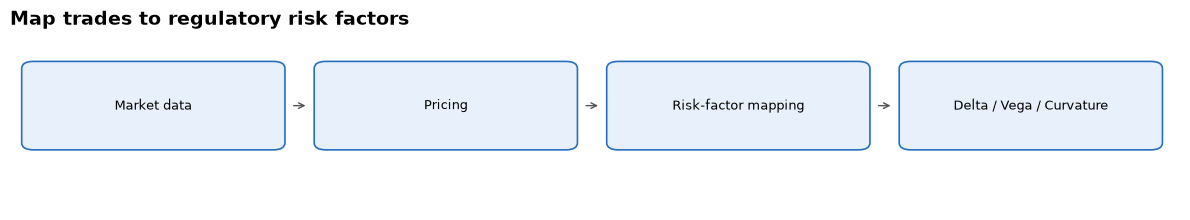

In [2]:
draw_flow(['Market data', 'Pricing', 'Risk-factor mapping', 'Delta / Vega / Curvature'],'Map trades to regulatory risk factors',wrap_after=4)

Each row keeps the risk class, bucket, exact factor, tenor, curve and location required for exact-factor netting.

$$\text{Trade}\longrightarrow\{\text{risk class, bucket, factor, tenor, curve, location}\}$$

In [3]:
mapping=pd.read_csv(RUN/'03_delta_trade_level.csv')
mapping['tenor_display']=mapping.apply(
    lambda row:f"{row.tenor:g} years" if pd.notna(row.tenor)
    else 'Not applicable for this risk factor',axis=1)
columns=['trade_id','desk','instrument_type','currency','risk_class','bucket','risk_factor_id','tenor_display','market_group']
display_sample(mapping[columns],35)
print('One foreign corporate bond becomes these separate rows:')
display(mapping[mapping.trade_id=='C02'][columns])
counts=mapping.groupby(['trade_id','instrument_type']).size().rename('number_of_risk_factors').reset_index()
display_sample(counts.sort_values('number_of_risk_factors',ascending=False),12)

Displayed rows: first 35 of 106 observations, in table order.


,trade_id,desk,instrument_type,currency,risk_class,bucket,risk_factor_id,tenor_display,market_group
0,R01,Rates,BOND,INR,GIRR,INR,INR_OIS_2.0Y,2 years,rates
1,R02,Rates,BOND,INR,GIRR,INR,INR_OIS_5.0Y,5 years,rates
2,R03,Rates,BOND,INR,GIRR,INR,INR_OIS_10.0Y,10 years,rates
3,R04,Rates,BOND,USD,GIRR,USD,USD_OIS_5.0Y,5 years,rates
4,R04,Rates,BOND,USD,FX,USD,USDINR,Not applicable for this risk factor,fx
5,R05,Rates,BOND,EUR,GIRR,EUR,EUR_OIS_10.0Y,10 years,rates
6,R05,Rates,BOND,EUR,FX,EUR,EURINR,Not applicable for this risk factor,fx
7,R06,Rates,IRS,INR,GIRR,INR,INR_OIS_5.0Y,5 years,rates
8,R07,Rates,IRS,USD,GIRR,USD,USD_OIS_10.0Y,10 years,rates
9,R07,Rates,IRS,USD,FX,USD,USDINR,Not applicable for this risk factor,fx


One foreign corporate bond becomes these separate rows:


,trade_id,desk,instrument_type,currency,risk_class,bucket,risk_factor_id,tenor_display,market_group
22,C02,Credit,CORPORATE_BOND,USD,GIRR,USD,USD_OIS_5.0Y,5 years,rates
23,C02,Credit,CORPORATE_BOND,USD,GIRR,USD,USD_OIS_10.0Y,10 years,rates
24,C02,Credit,CORPORATE_BOND,USD,CSR_NON_SECURITISATION,4,US_INDUSTRIAL_5.0Y,5 years,credit_spreads
25,C02,Credit,CORPORATE_BOND,USD,CSR_NON_SECURITISATION,4,US_INDUSTRIAL_10.0Y,10 years,credit_spreads
26,C02,Credit,CORPORATE_BOND,USD,FX,USD,USDINR,Not applicable for this risk factor,fx


Displayed rows: first 12 of 46 observations, in table order.


,trade_id,instrument_type,number_of_risk_factors
7,C08,CALLABLE_BOND,5
1,C02,CORPORATE_BOND,5
41,R12,XCCY_BASIS_SWAP,4
3,C04,CORPORATE_BOND,4
45,T02,CTP_INDEX_HEDGE,3
29,M07,COMMODITY_OPTION,3
19,F02,FX_FORWARD,3
20,F03,FX_OPTION,3
21,F04,FX_OPTION,3
22,F05,DIGITAL_OPTION,3


The visual below uses the calculated rows shown above.

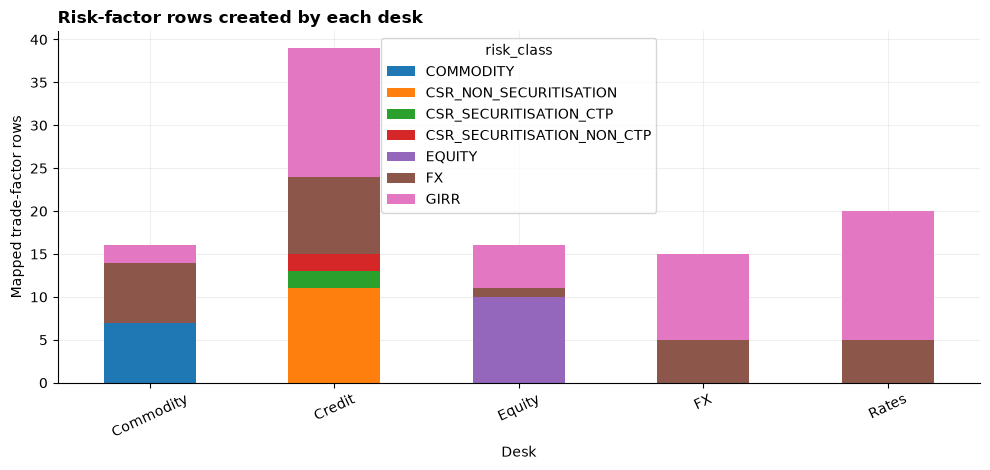

In [4]:
links=mapping.groupby(['desk','risk_class']).size().unstack(fill_value=0)
links.plot(kind='bar',stacked=True)
plt.title('Risk-factor rows created by each desk',loc='left',weight='bold')
plt.ylabel('Mapped trade-factor rows'); plt.xlabel('Desk'); plt.xticks(rotation=25)
plt.tight_layout(); plt.show()

The portfolio is now granular enough to calculate one-factor-at-a-time sensitivities.